[I 2025-01-11 02:00:54,090] A new study created in memory with name: no-name-c4aec275-9d23-4fa3-ac08-bac75f7976a1
C:\Users\domin\AppData\Local\Temp\ipykernel_23424\2089135992.py:49: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-5, 1e-1)
[I 2025-01-11 02:01:45,802] Trial 0 finished with value: 0.185746343246401 and parameters: {'lr': 0.0913110422595484}. Best is trial 0 with value: 0.185746343246401.
[I 2025-01-11 02:02:38,307] Trial 1 finished with value: 0.18574902084844708 and parameters: {'lr': 0.00010693351682758371}. Best is trial 0 with value: 0.185746343246401.
[I 2025-01-11 02:03:30,872] Trial 2 finished with value: 0.18574124615965112 and parameters: {'lr': 0.0012589826090819857}. Best is trial 2 with value: 0.18574124615965112.
[I 2025-01-11 02:04:23,360] Trial 3 finished with va

Najlepsze parametry: {'lr': 5.068193556805844e-05}


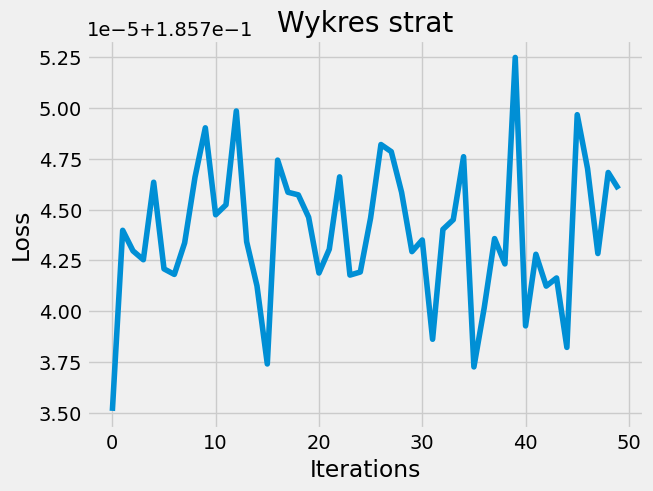

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import optuna

# 1. Przygotowanie danych
tensor_transform = transforms.ToTensor()

# Pobranie danych MNIST
train_dataset = datasets.FashionMNIST(root='../fashion-mnist/data', train=True, transform=tensor_transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# 2. Definicja modelu
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512),  # Warstwa ukryta
            nn.ReLU(),
            nn.Linear(512, 10)  # Warstwa wyjściowa
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(10, 512), nn.ReLU(),
            nn.Linear(512, 28 * 28), nn.Sigmoid(),
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = NeuralNetwork()

# 3. Konfiguracja procesu uczenia
criterion = nn.MSELoss()  # Funkcja straty
optimizer = optim.RMSprop(model.parameters(), lr=0.001)  # Optymalizator RMSprop

# 4. Trenowanie modelu
epochs = 5
losses = []

# Funkcja celu do optymalizacji (Optuna)
def objective(trial):
    # Testowanie różnych hiperparametrów, np. learning_rate
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-1)
    optimizer = optim.RMSprop(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        epoch_loss = 0
        for image, _ in train_loader:
            image = image.reshape(-1, 28 * 28)  # Zmiana kształtu obrazu
            
            reconstruction = model(image)
            
            loss = criterion(reconstruction, image)
            
            optimizer.zero_grad()  # Wyzerowanie gradientów
            loss.backward()  # Backpropagation
            optimizer.step()  # Aktualizacja wag
            
            epoch_loss += loss.item()
        losses.append(epoch_loss / len(train_loader))  # Dodanie średniej straty na epokę
    
    return epoch_loss / len(train_loader)

# Optymalizacja hiperparametrów
study = optuna.create_study()
study.optimize(objective, n_trials=10)

print("Najlepsze parametry:", study.best_params)

# 5. Wykres strat
plt.style.use('fivethirtyeight')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.plot(losses)
plt.title("Wykres strat")
plt.show()


C:\semestr7\MachineLearningV2\lab1\pythonProject\.venv\Lib\site-packages\torch\_tensor.py:955: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


C:\Users\domin\AppData\Local\Temp\ipykernel_23424\3540989096.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


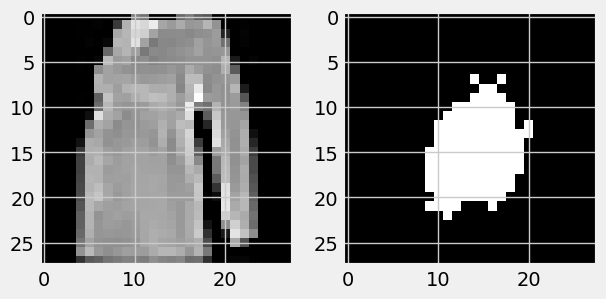

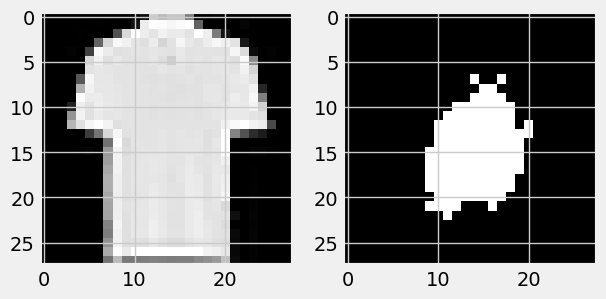

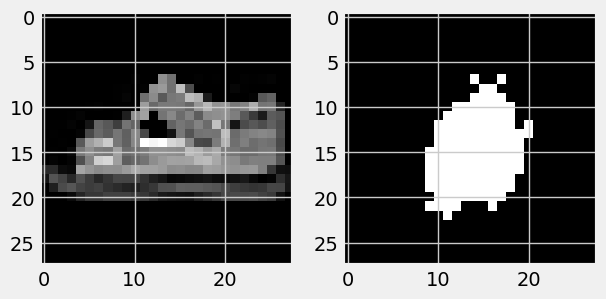

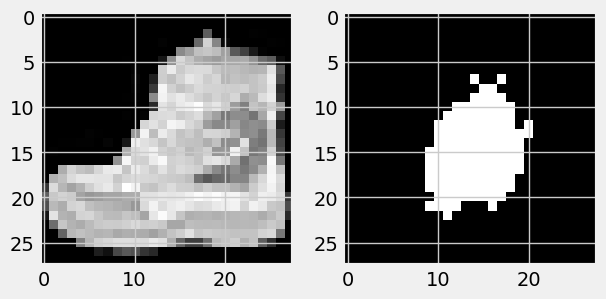

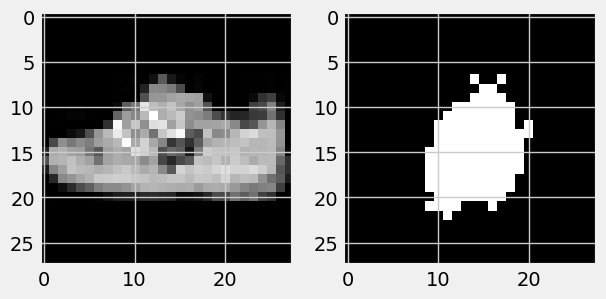

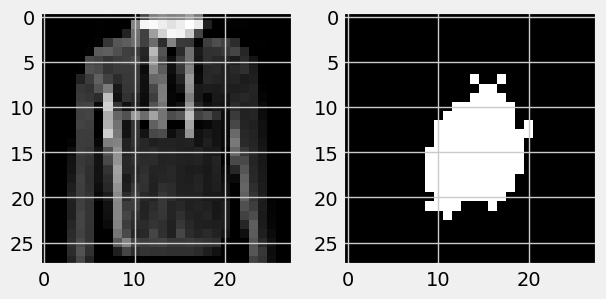

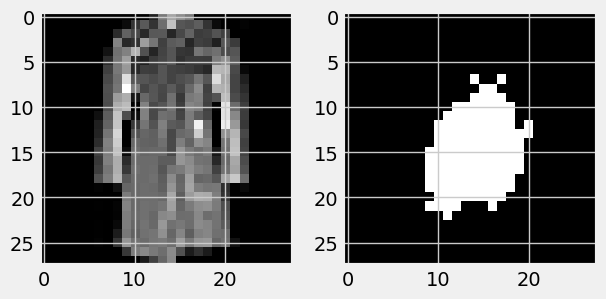

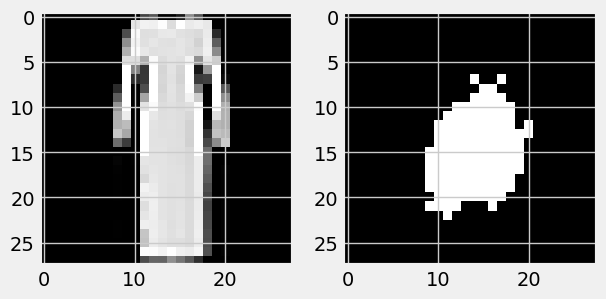

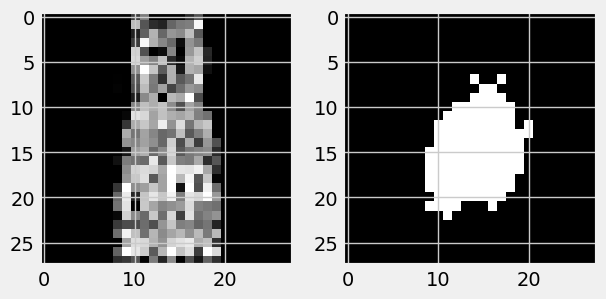

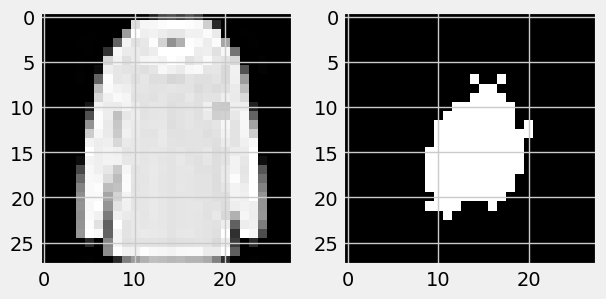

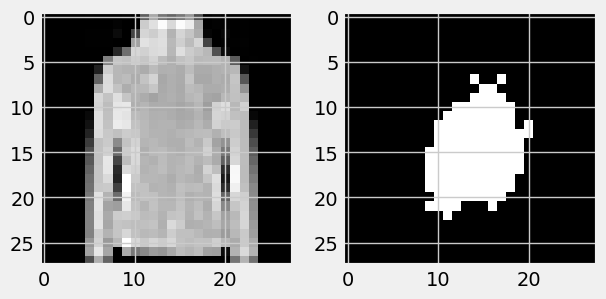

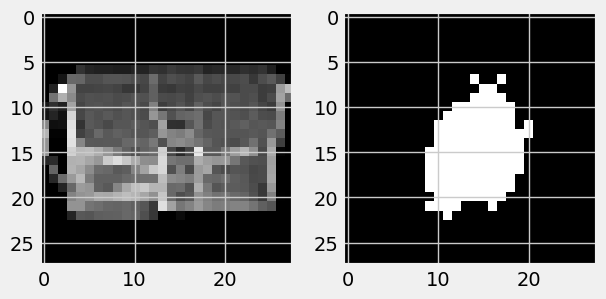

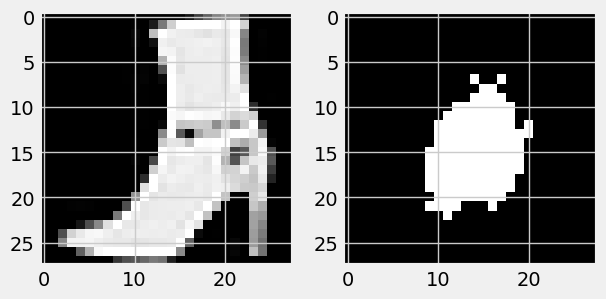

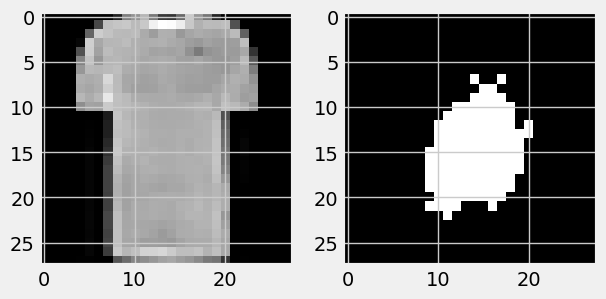

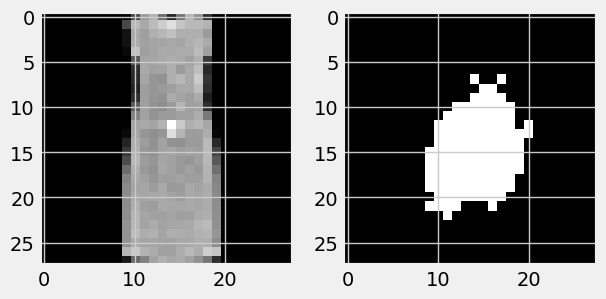

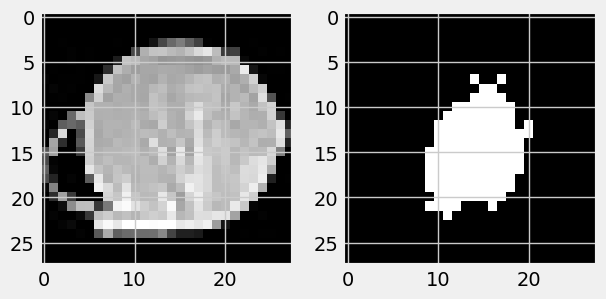

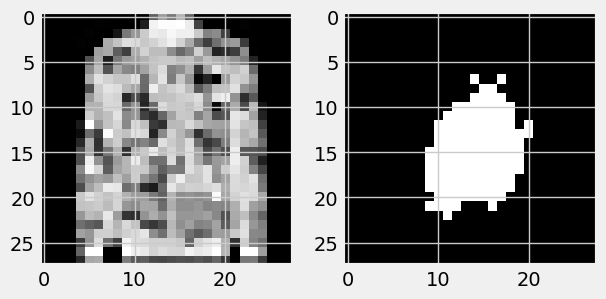

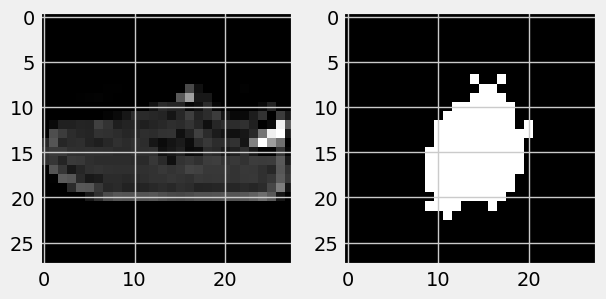

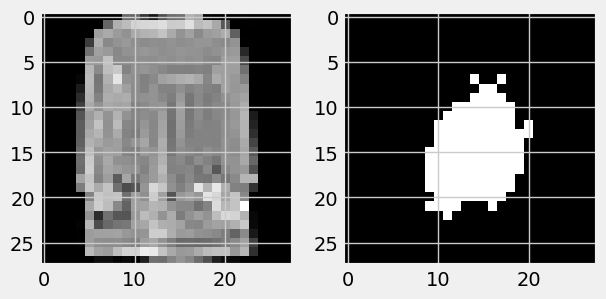

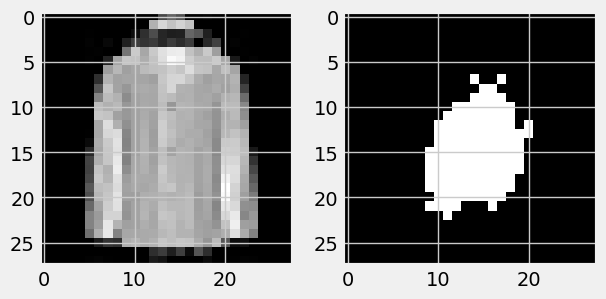

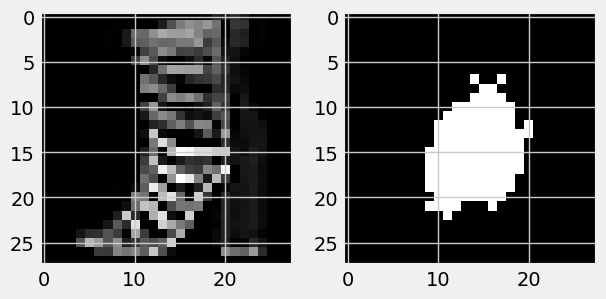

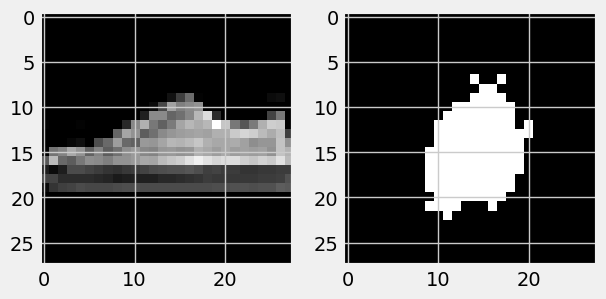

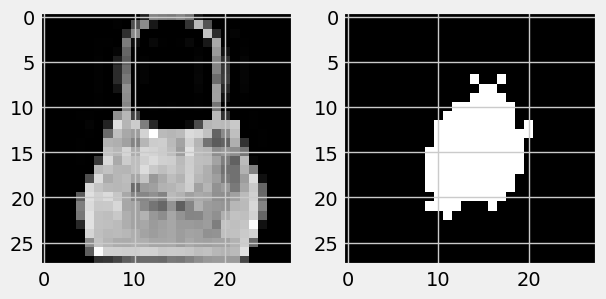

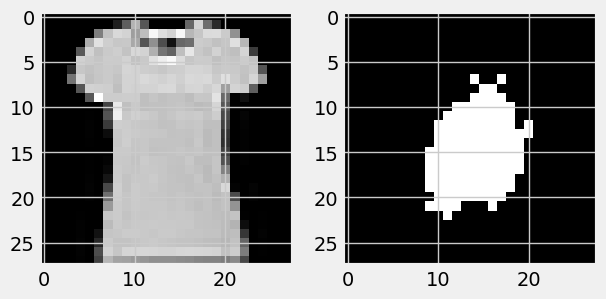

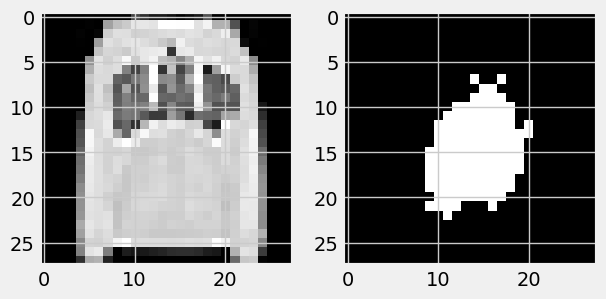

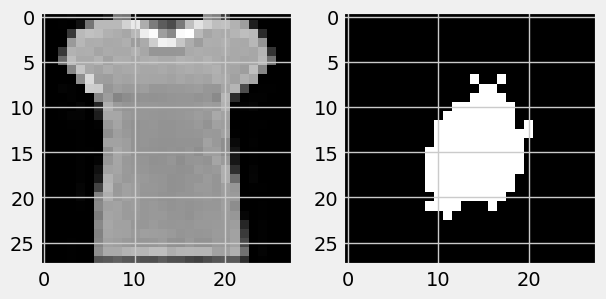

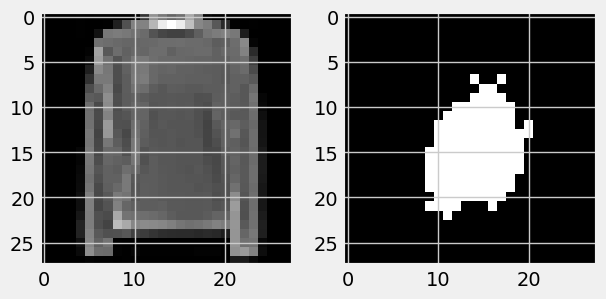

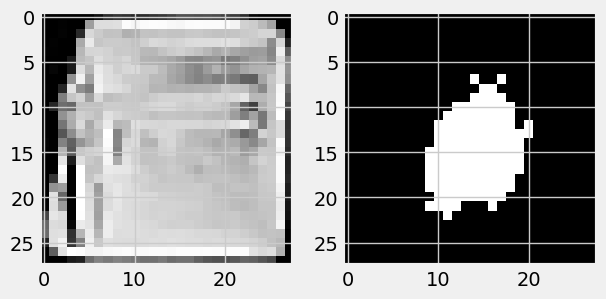

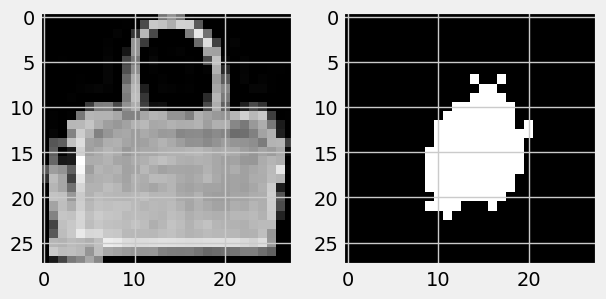

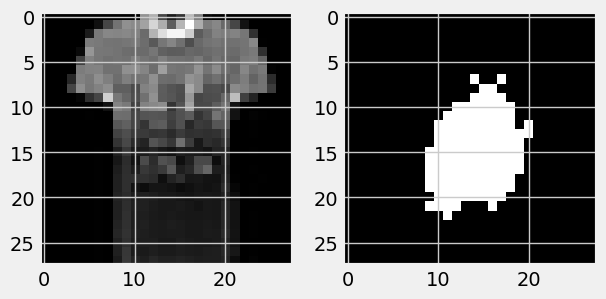

In [7]:
for i in range(30):
    tensor1 = outputs[0][1][i]
    plt.figure()
    plt.subplot(1, 2, 1)
    plt.imshow(tensor1.resize(28,28), cmap="gray")
    plt.subplot(1, 2, 2)
    tensor = model(tensor1).detach()
    plt.imshow(tensor.resize(28,28), cmap="gray")
    print(type(outputs[0][2]))